In [1]:
!pip install --upgrade scikit-learn scikit-learn==1.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 74.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


<a id = "1"></a><br>
# Load Python Pakages


In [2]:
#basics
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
import time

#preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer, quantile_transform


#statistics
from scipy import stats
from scipy.stats import skew
from scipy.special import boxcox1p
from scipy.stats import randint

#feature engineering
from sklearn.feature_selection import mutual_info_regression


#transformers and pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import set_config


#algorithms
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.isotonic import IsotonicRegression


#model evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate, cross_val_predict, train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, make_scorer, mean_squared_log_error
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_slice


#stacking
from sklearn.ensemble import StackingRegressor

#feature selection
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFECV

random_state = 42


<a id = "2"></a><br>
#  First look to data

In [3]:
# Read the data
train = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv', index_col=[0])
test = pd.read_csv('/kaggle/input/playground-series-s5e9/test.csv', index_col=[0])
original = pd.read_csv('/kaggle/input/bpm-prediction-challenge/Train.csv')
original.index.names = ['id']


In [4]:

original.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.513080,-7.811659,0.071013,0.064564,0.109495,0.316042,0.736929,328639.3188,0.556200,117.092439
1,0.775393,-6.819409,0.023500,0.510599,0.187498,0.024361,0.259488,271967.9826,0.410533,122.002279
2,0.636408,-19.782248,0.063451,0.427861,0.002226,0.024300,0.054848,186147.0029,0.533333,149.130616
3,0.232190,-14.957299,0.023500,0.076268,0.000001,0.228454,0.744650,321734.9723,0.658533,95.832178
4,0.758564,-4.715966,0.023500,0.263551,0.414794,0.197167,0.966592,179973.3982,0.230467,125.696263


In [5]:
#train = pd.concat([train, original], ignore_index=True)

# reserved for pipeline
pipe_data = train.copy()
pipe_test = test.copy()
pipe_original = original.copy()

# use for preliminary analysis
train_df = train.copy()
test_df = test.copy()
original_df = original.copy()
train_df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


<a id = "3"></a><br>
# Exploratory Data Analysis

<a id = "4"></a><br>
## Descpriptive statistics 

In [6]:
#descriptive statistics
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
RhythmScore,524164.0,0.632843,0.156899,0.076900,0.515850,0.634686,0.739179,0.975000
AudioLoudness,524164.0,-8.379014,4.616221,-27.509725,-11.551933,-8.252499,-4.912298,-1.357000
VocalContent,524164.0,0.074443,0.049939,0.023500,0.023500,0.066425,0.107343,0.256401
AcousticQuality,524164.0,0.262913,0.223120,0.000005,0.069413,0.242502,0.396957,0.995000
InstrumentalScore,524164.0,0.117690,0.131845,0.000001,0.000001,0.074247,0.204065,0.869258
LivePerformanceLikelihood,524164.0,0.178398,0.118186,0.024300,0.077637,0.166327,0.268946,0.599924
MoodScore,524164.0,0.555843,0.225480,0.025600,0.403921,0.564817,0.716633,0.978000
TrackDurationMs,524164.0,241903.692949,59326.601501,63973.000000,207099.876625,243684.058150,281851.658500,464723.228100
Energy,524164.0,0.500923,0.289952,0.000067,0.254933,0.511800,0.746000,1.000000
BeatsPerMinute,524164.0,119.034899,26.468077,46.718000,101.070410,118.747660,136.686590,206.037000


<a id = "5"></a><br>

## Grouping features for preprocessing purposes

In [7]:
numerical_features = [feature for feature in train.columns if not feature  == "BeatsPerMinute"]

target = "BeatsPerMinute"


In [8]:
#sample data for eda
sampled_df = train_df.sample(frac = 0.01)

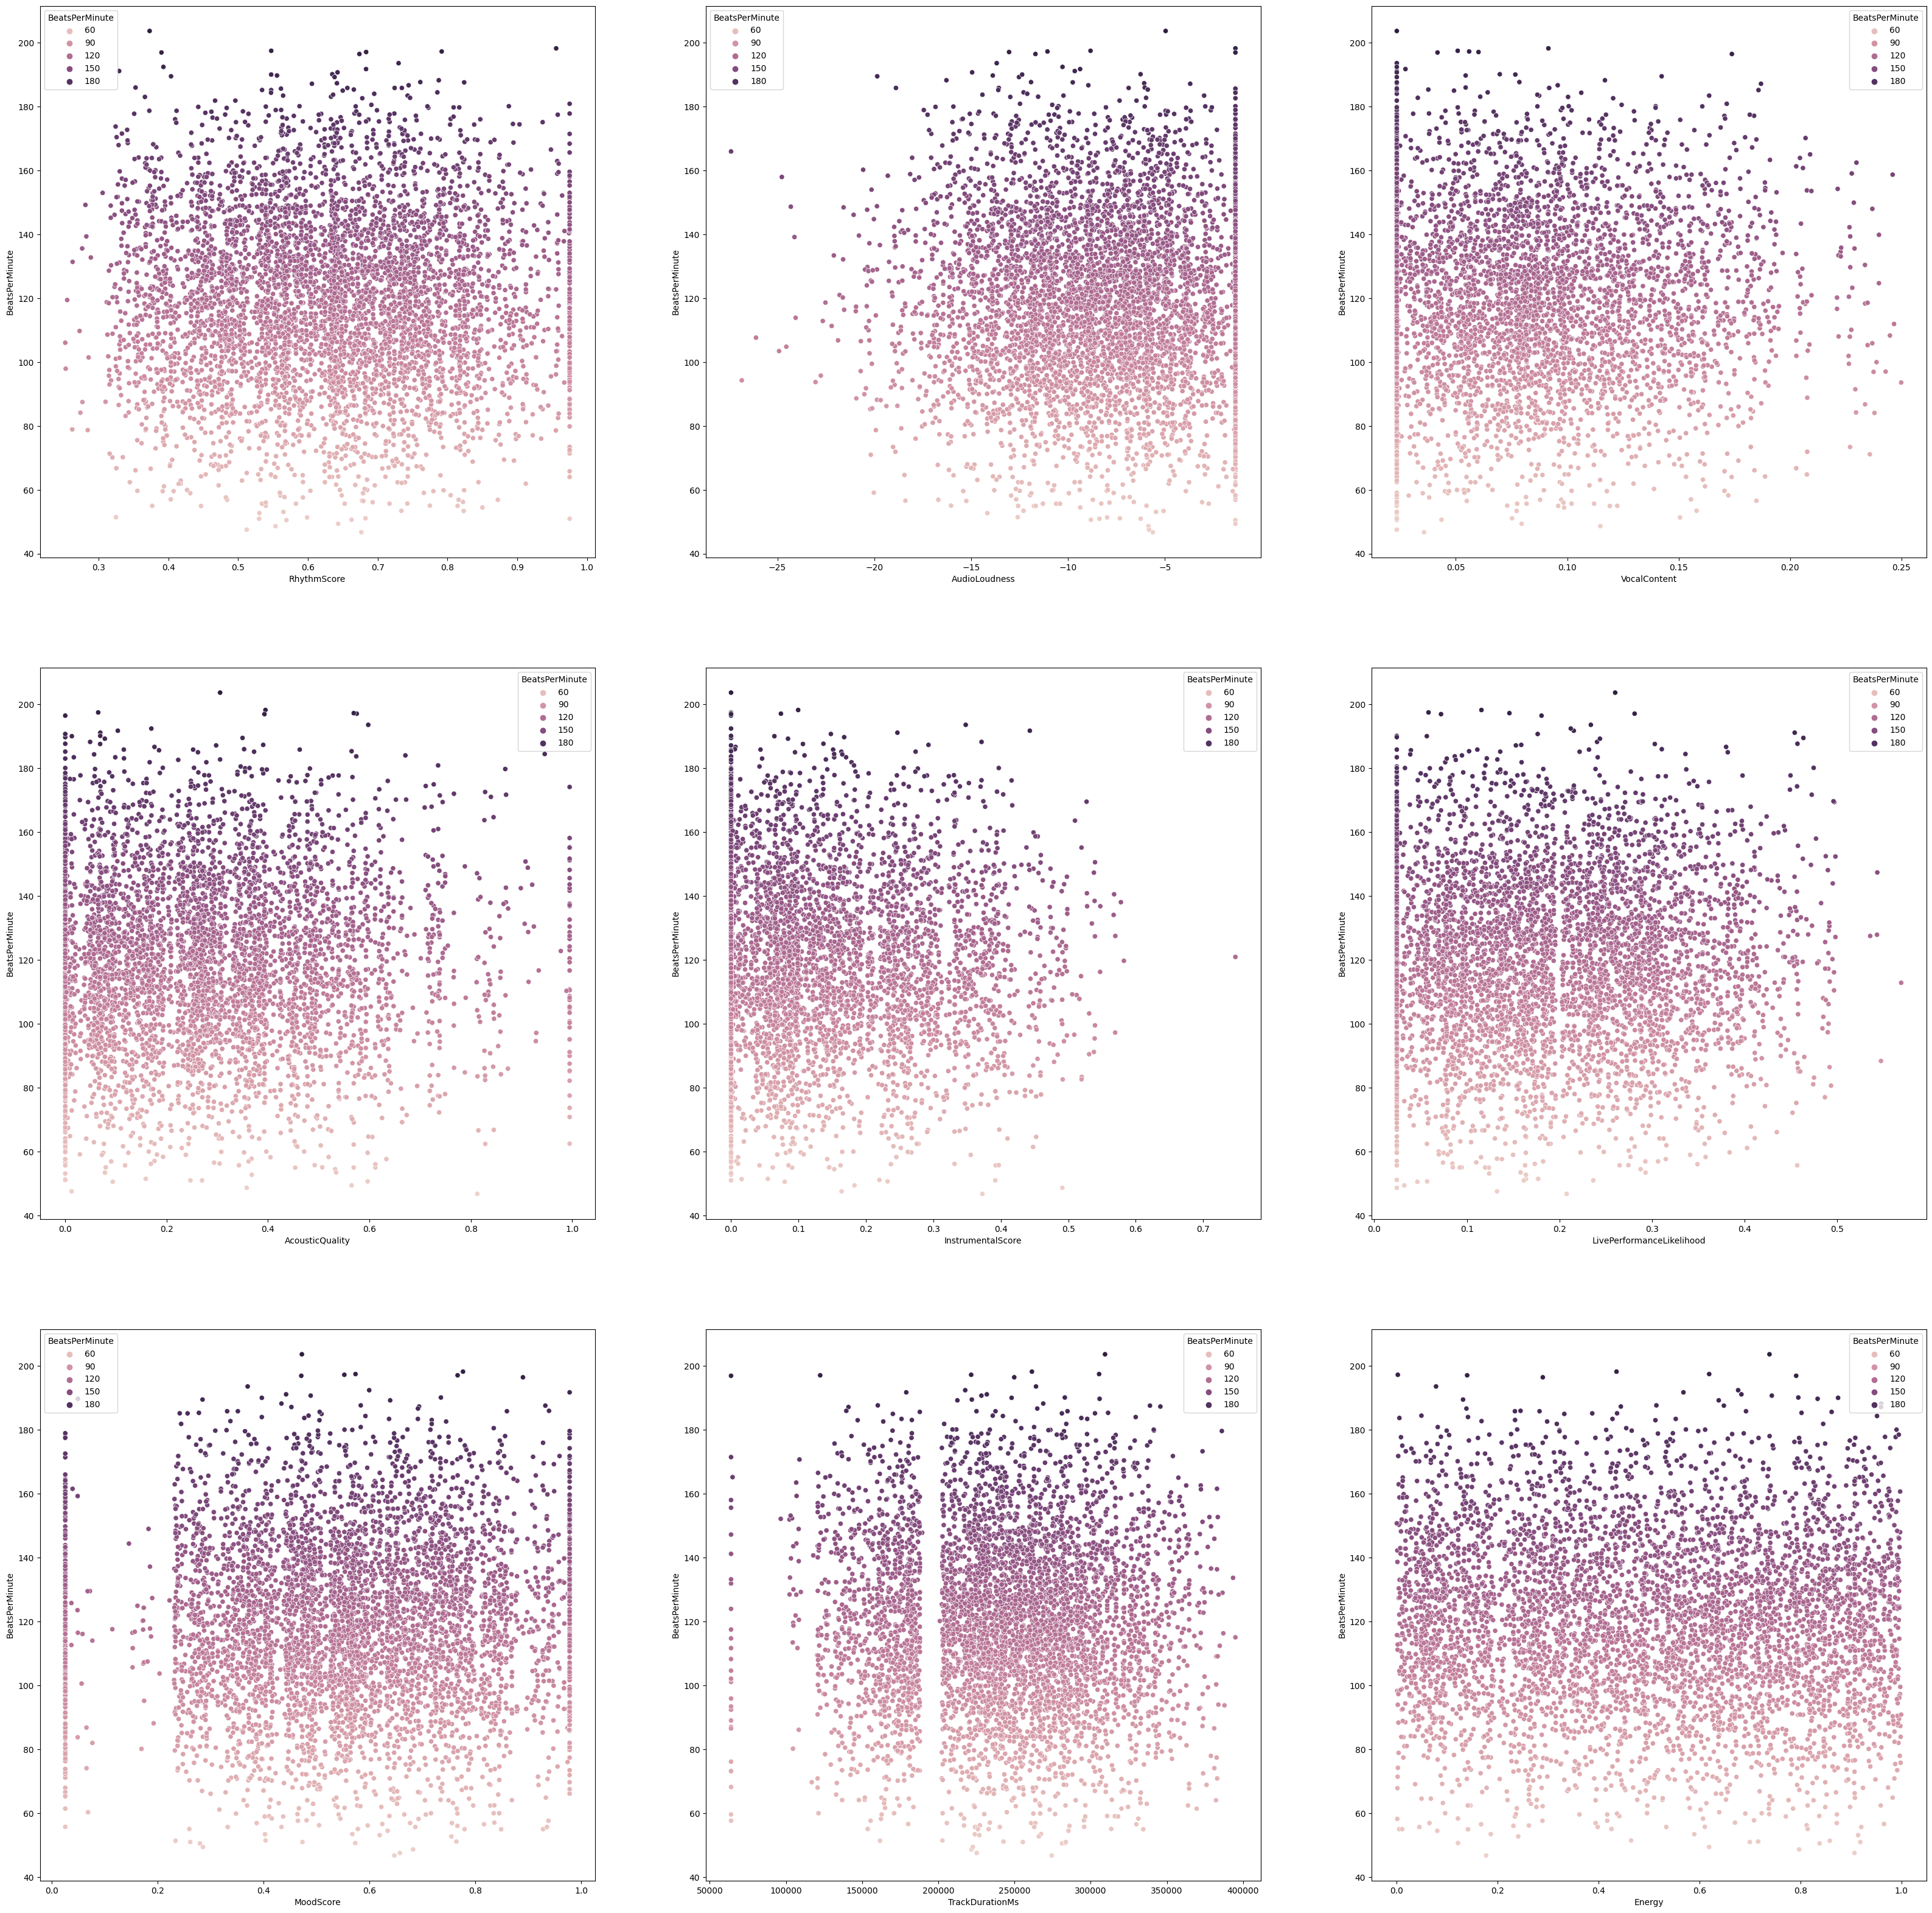

In [9]:
fig, ax = plt.subplots(3, 3, figsize=(40, 40))
for var, subplot in zip(numerical_features, ax.flatten()):
    sns.scatterplot(x=var, y='BeatsPerMinute',  data=sampled_df, ax=subplot, hue = 'BeatsPerMinute' )
    

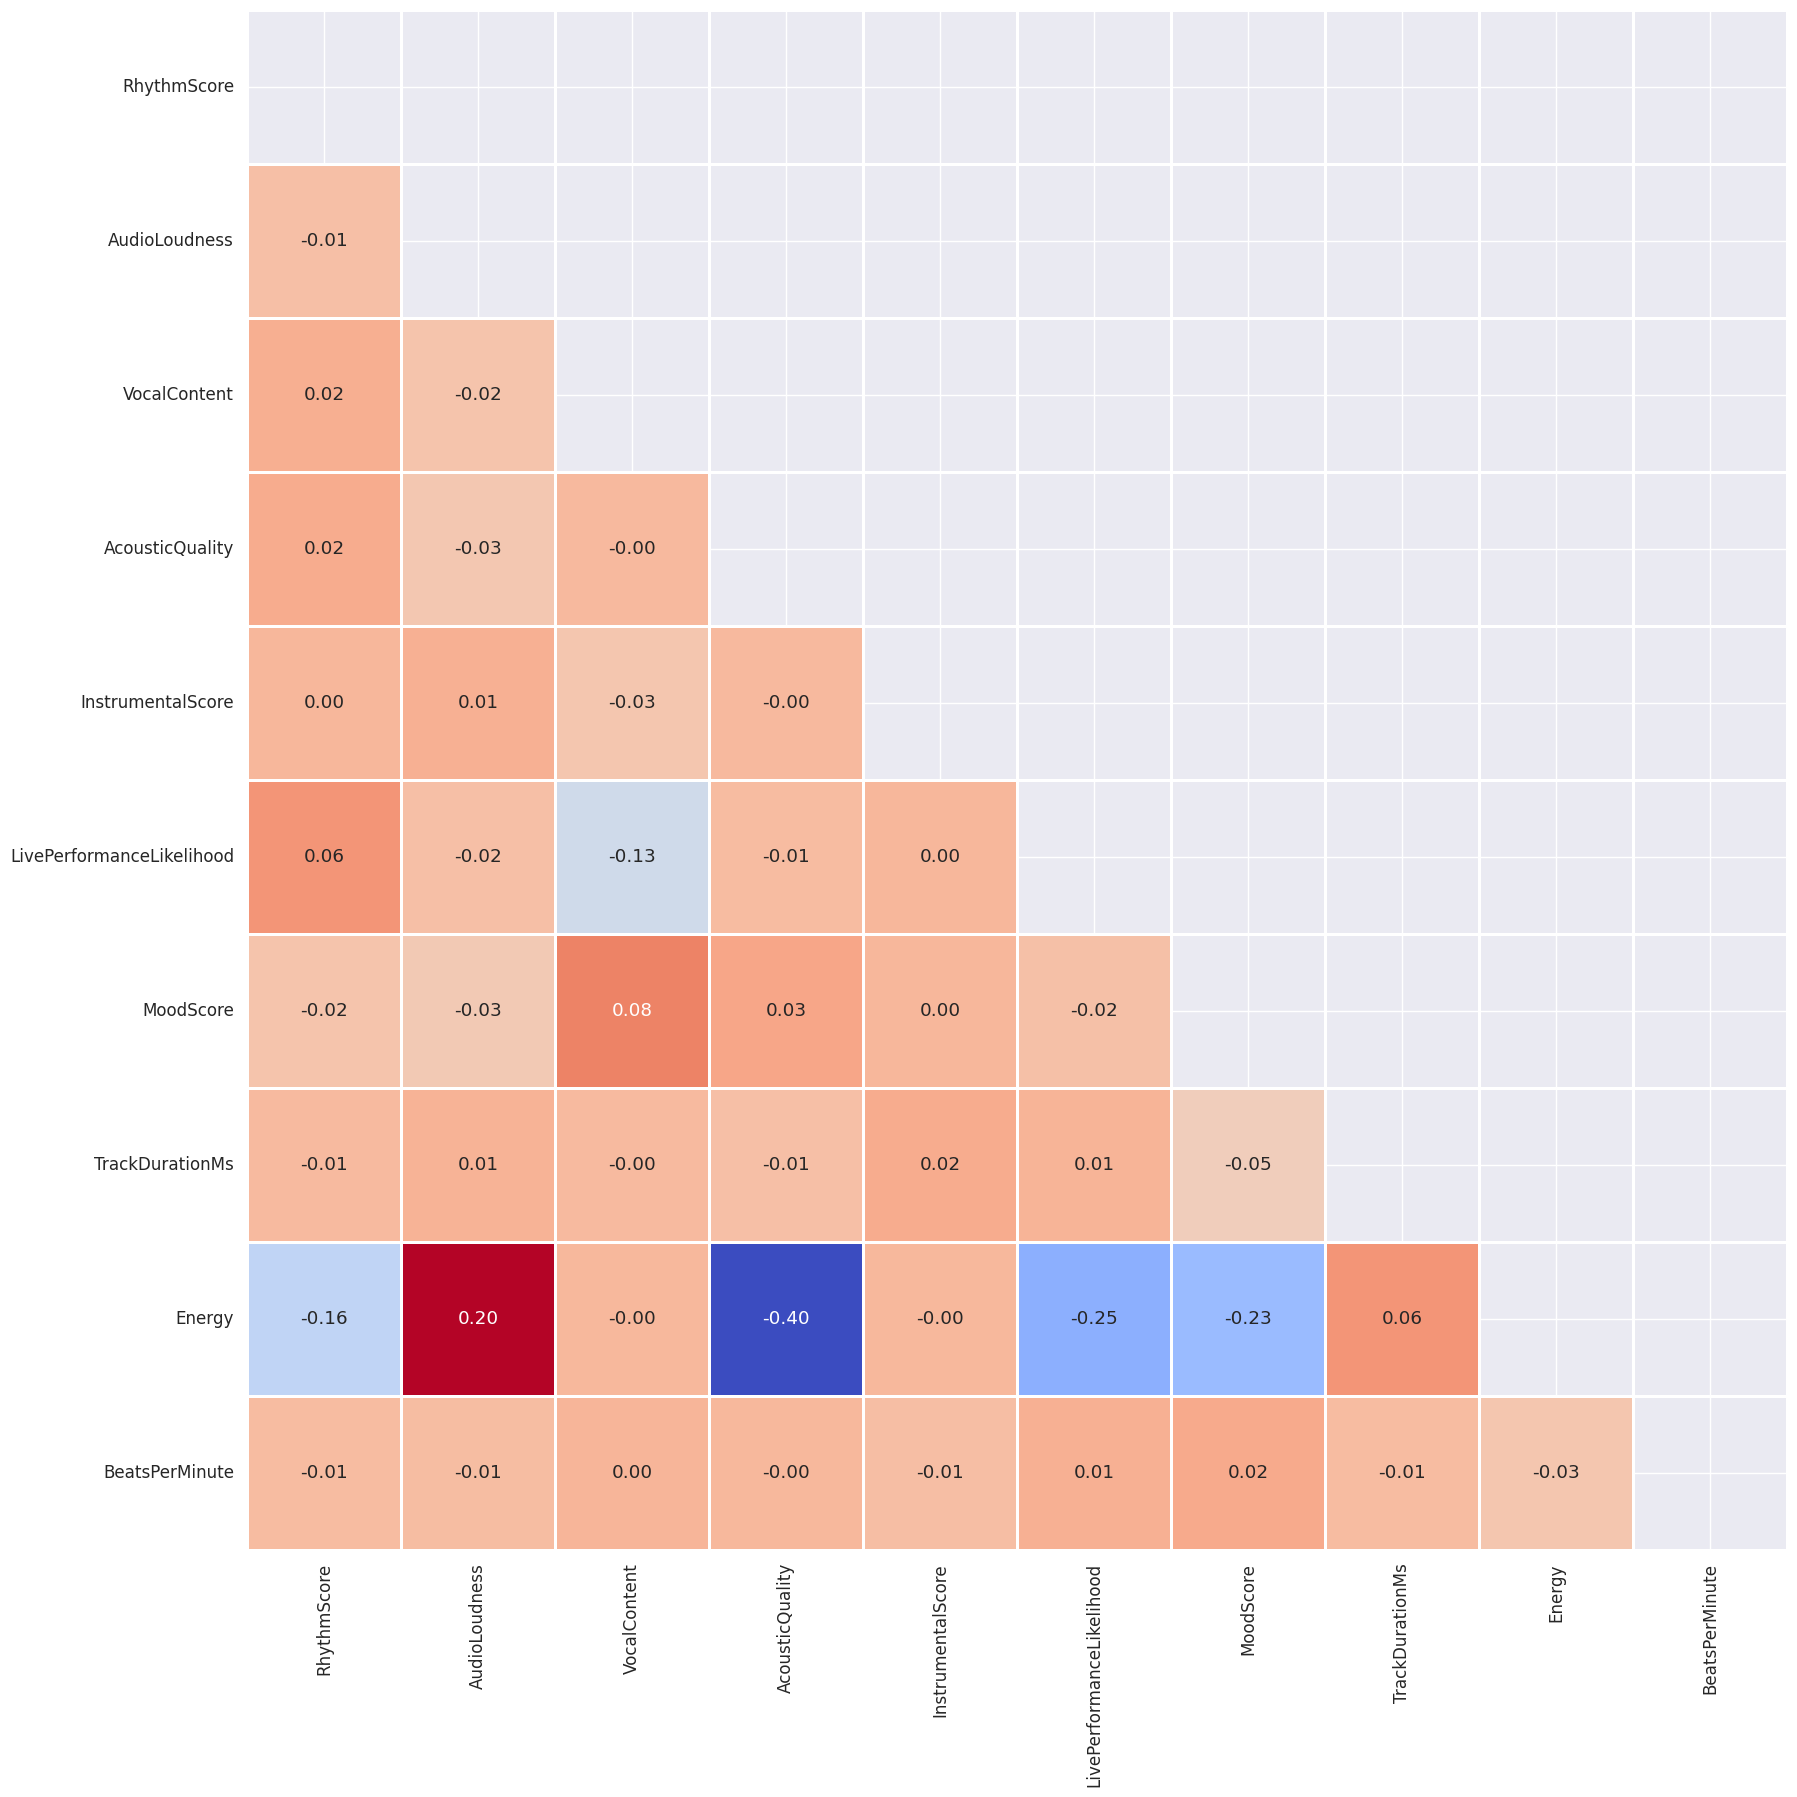

In [10]:
# Display correlations between numerical features and target on heatmap.

sns.set(font_scale=1.1)
correlation_train = sampled_df.corr()
mask = np.triu(correlation_train.corr())
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_train,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            mask=mask,
            linewidths=1,
            cbar=False);

In [11]:
# Mutual Information score
y_sampled = sampled_df.BeatsPerMinute
mutual_df = sampled_df[numerical_features ]

mutual_info = mutual_info_regression(mutual_df, y_sampled, random_state=random_state)

mutual_info = pd.Series(mutual_info)
mutual_info.index = mutual_df.columns
mutual_info = pd.DataFrame(mutual_info.sort_values(ascending=False), columns = ["Numerical_Feature_MI"] )
mutual_info.style.background_gradient("cool")

,Numerical_Feature_MI
TrackDurationMs,0.024744
LivePerformanceLikelihood,0.023348
RhythmScore,0.005808
InstrumentalScore,0.005238
AudioLoudness,0.003846
Energy,0.003836
VocalContent,0.000000
AcousticQuality,0.000000
MoodScore,0.000000


## Target Distribution

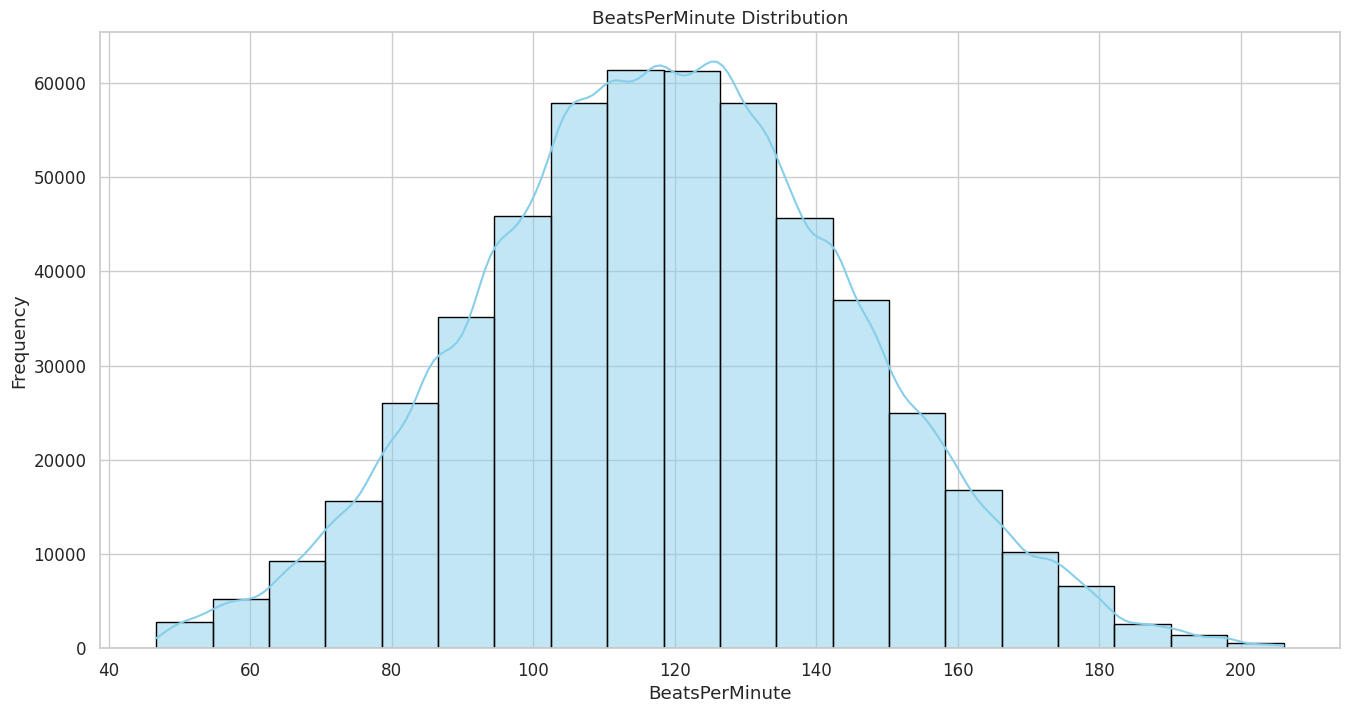

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))

# Create the histogram plot
sns.histplot(x='BeatsPerMinute', data=train_df, bins=20, kde=True, color='skyblue', edgecolor='black')

# Add title and labels
plt.title('BeatsPerMinute Distribution')
plt.xlabel('BeatsPerMinute')
plt.ylabel('Frequency')

# Show the plot
plt.show()

<a id = "6"></a><br>
# Feature Engineering (maybe later)

<a id = "7"></a><br>
# A custom pipeline for Feature Engineering

In [13]:
#Just a place holder not applied any FE for now

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, add_attributes=True):
        self.add_attributes = add_attributes
        self.new_feature_names = []  # Placeholder for future engineered features
    
    def fit(self, X, y=None):
        # Placeholder fit method
        return self
    
    def transform(self, X):
        # Placeholder transform method
        return X
    
    def get_feature_names_out(self, input_features=None):
        # Placeholder method for output feature names
        if self.add_attributes:
            return self.new_feature_names
        else:
            return list(input_features) if input_features is not None else []


In [14]:
FeatureEngineer = FeatureEngineer()

<a id = "8"></a><br>
# Preprocessing

In [15]:
# Preprocessing object for linear models
numerical_transformer =  StandardScaler()

In [16]:
# Preprocessing object for neural net
nn_preprocessor = MinMaxScaler()

<a id = "9"></a><br>
# Modeling

Hyperparameter optimization is performed with Optuna. You can find Optuna settings for different models in the Appendix.

In [17]:
cv = KFold(n_splits= 10, shuffle=True, random_state=random_state)

In [18]:
def cross_validate_score(
    model, 
    data, 
    cv, 
    label='BeatsPerMinute', 
    include_original=True, 
    early_stopping_patience=50
):
    X = data.copy()
    y = X.pop(label)
    
    # Initiate prediction arrays and score lists
    val_predictions = np.zeros(len(X))
    train_scores, val_scores = [], []
    test_predictions = np.zeros(len(pipe_test))

    # Training model and evaluating metrics
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        # Define train and validation sets for the current fold
        X_train, y_train = X.iloc[train_idx].reset_index(drop=True), y.iloc[train_idx].reset_index(drop=True)
        X_val, y_val = X.iloc[val_idx].reset_index(drop=True), y.iloc[val_idx].reset_index(drop=True)
        
        if include_original:
            X_train = pd.concat([pipe_original.drop(label, axis=1), X_train]).reset_index(drop=True)
            y_train = pd.concat([pipe_original[label], y_train]).reset_index(drop=True)

        # --- DYNAMIC EARLY STOPPING LOGIC ---
        fit_params = {}
        if early_stopping_patience is not None:
            # Handle XGBoost and CatBoost which use 'early_stopping_rounds'
            if isinstance(model, (XGBRegressor, CatBoostRegressor)):
                fit_params['early_stopping_rounds'] = early_stopping_patience
                fit_params['eval_set'] = [(X_val, y_val)]
                fit_params['verbose'] = False
            
            # Handle LightGBM which uses 'callbacks'
            elif isinstance(model, LGBMRegressor):
                fit_params['callbacks'] = [early_stopping(stopping_rounds=early_stopping_patience)]
                fit_params['eval_set'] = [(X_val, y_val)]

        # Train the model, unpacking fit_params if early stopping is applicable
        model.fit(X_train, y_train, **fit_params)

        # Make predictions
        train_preds = model.predict(X_train)
        val_preds = model.predict(X_val)
                  
        val_predictions[val_idx] += val_preds
        test_predictions += model.predict(pipe_test) / cv.get_n_splits()
        
        # Evaluate model for the fold (RMSE)
        train_score = np.sqrt(mean_squared_error(y_train, train_preds))
        val_score = np.sqrt(mean_squared_error(y_val, val_preds))
        print(f'Fold {fold}: RMSE {val_score:.5f}')
        
        # Append scores
        train_scores.append(train_score)
        val_scores.append(val_score)

    print(f'Val RMSE: {np.mean(val_scores):.7f} ± {np.std(val_scores):.7f} | Train RMSE: {np.mean(train_scores):.7f} ± {np.std(train_scores):.7f} | {label}')
        
    return val_scores, val_predictions, test_predictions

In [19]:
cv_summary, oof_predictions_df, submission_predictions_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

<a id = "10"></a><br>
## Linear Model (Ridge)

In [20]:
ridge_optuna_params = {'max_iter': 969,
                       'alpha': 996.2276353844511,
                       'tol': 4.41828902390748e-05}

ridge_tuned = Ridge(**ridge_optuna_params, random_state=random_state)

ridge_pipe = Pipeline(steps=[
    #('FeatureEngineer', FeatureEngineer),
    ('numerical_transformer', numerical_transformer),
    ('ridge', ridge_tuned)
])

ridge_pipe

,steps,"[('numerical_transformer', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,996.2276353844511
,fit_intercept,True
,copy_X,True
,max_iter,969


In [21]:
%%time
cv_summary['ridge'], oof_predictions_df['ridge'], submission_predictions_df['ridge'] = cross_validate_score(ridge_pipe, data = pipe_data,cv=cv, include_original=True, early_stopping_patience= None)

Fold 0: RMSE 26.44004
Fold 1: RMSE 26.44697
Fold 2: RMSE 26.52109
Fold 3: RMSE 26.46170
Fold 4: RMSE 26.52926
Fold 5: RMSE 26.52826
Fold 6: RMSE 26.45228
Fold 7: RMSE 26.44987
Fold 8: RMSE 26.40901
Fold 9: RMSE 26.42256
Val RMSE: 26.4661044 ± 0.0418931 | Train RMSE: 26.4687255 ± 0.0045164 | BeatsPerMinute
CPU times: user 3.87 s, sys: 975 ms, total: 4.85 s
Wall time: 3.37 s


<a id = "11"></a><br>
## XGboost

In [22]:
xgb_optuna_params = {
    "alpha": 0.05334153651080927,
    "subsample": 0.8291422252359604,
    "colsample_bytree": 0.8448513960069721,
    "max_depth": 5,
    "min_child_weight": 2,
    "learning_rate": 0.027468615352585563,
    "gamma": 2.345888717850157e-08,
} 

xgb_tuned = XGBRegressor(
    **xgb_optuna_params,
    random_state=random_state
)

xgb_pipe = Pipeline(steps=[
    # ('FeatureEngineer', FeatureEngineer),
    ('xgb_tuned', xgb_tuned)
])

xgb_pipe


,steps,"[('xgb_tuned', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8448513960069721


In [23]:
%%time
cv_summary['xgb'], oof_predictions_df['xgb'], submission_predictions_df['xgb'] = cross_validate_score(xgb_pipe, data = pipe_data,cv=cv, include_original=True, early_stopping_patience= None)

Fold 0: RMSE 26.43528
Fold 1: RMSE 26.44346
Fold 2: RMSE 26.51309
Fold 3: RMSE 26.45673
Fold 4: RMSE 26.52169
Fold 5: RMSE 26.52527
Fold 6: RMSE 26.44324
Fold 7: RMSE 26.44318
Fold 8: RMSE 26.40385
Fold 9: RMSE 26.41578
Val RMSE: 26.4601568 ± 0.0417732 | Train RMSE: 26.4341085 ± 0.0046009 | BeatsPerMinute
CPU times: user 1min 35s, sys: 849 ms, total: 1min 36s
Wall time: 26 s


In [24]:
xgb_optuna_params = {
    "alpha": 1.1417895360918512e-08,
    "subsample": 0.8672968424260418,
    "colsample_bytree": 0.8928420787256,
    "max_depth": 5,
    "n_estimators": 10000,  
    "min_child_weight": 2,
    "learning_rate": 0.043364117455284894,
    "gamma": 1.994813646688927e-07,
}

xgb_tuned2 = XGBRegressor(
    **xgb_optuna_params,
    random_state=random_state,
    n_jobs=-1,
    tree_method="hist"
)


In [25]:
%%time
cv_summary['xgb2'], oof_predictions_df['xgb2'], submission_predictions_df['xgb2'] = cross_validate_score(
    xgb_tuned2, 
    data=pipe_data, 
    cv=cv, 
    include_original=True, 
    early_stopping_patience=150
)


Fold 0: RMSE 26.43472
Fold 1: RMSE 26.44320
Fold 2: RMSE 26.51339
Fold 3: RMSE 26.45690
Fold 4: RMSE 26.52057
Fold 5: RMSE 26.52458
Fold 6: RMSE 26.44262
Fold 7: RMSE 26.44163
Fold 8: RMSE 26.40311
Fold 9: RMSE 26.41612
Val RMSE: 26.4596843 ± 0.0417385 | Train RMSE: 26.4306447 ± 0.0172804 | BeatsPerMinute
CPU times: user 3min 31s, sys: 1.04 s, total: 3min 32s
Wall time: 55.1 s


In [26]:
# Optuna best (Trial 65) -> packaged as xgb3
xgb3_optuna_params = {
    "learning_rate": 0.04720276350620546,
    "max_depth": 5,
    "min_child_weight": 8,
    "gamma": 1.7187299796168027e-07,
    "reg_alpha": 0.00014035316114796025,     
    "reg_lambda": 2.07921511088267e-08,       
    "subsample": 0.8588557403660569,
    "colsample_bytree": 0.9272347069993087,
    "grow_policy": "lossguide",
    "max_bin": 426,
    "max_leaves": 396,                       
    "n_estimators": 10000,                    
}

xgb3 = XGBRegressor(
    **xgb3_optuna_params,
    random_state=random_state,
    n_jobs=-1,
    tree_method="hist"
)

In [27]:
%%time
cv_summary['xgb3'], oof_predictions_df['xgb3'], submission_predictions_df['xgb3'] = cross_validate_score(
    xgb3,
    data=pipe_data,
    cv=cv,
    include_original=True,
    early_stopping_patience=50  
)

Fold 0: RMSE 26.43541
Fold 1: RMSE 26.44287
Fold 2: RMSE 26.51268
Fold 3: RMSE 26.45591
Fold 4: RMSE 26.52011
Fold 5: RMSE 26.52441
Fold 6: RMSE 26.44262
Fold 7: RMSE 26.43992
Fold 8: RMSE 26.40257
Fold 9: RMSE 26.41369
Val RMSE: 26.4590184 ± 0.0419399 | Train RMSE: 26.4273568 ± 0.0165107 | BeatsPerMinute
CPU times: user 2min 18s, sys: 1.16 s, total: 2min 19s
Wall time: 36.8 s


<a id = "12"></a><br>
## Lightgbm

In [28]:
lgbm_optuna_params = {
    'n_estimators': 934,
    'max_depth': 16,
    'learning_rate': 0.003717017250694586,
    'min_data_in_leaf': 56,
    'subsample': 0.939684807121632,
    'max_bin': 420,
    'feature_fraction': 0.8416988483664828
}

lgbm_tuned = LGBMRegressor(
    **lgbm_optuna_params,
    random_state=random_state,
    verbose=-1
)

lgbm_pipe = Pipeline(steps=[
    # ('FeatureEngineer', FeatureEngineer),
    ('lgbm_tuned', lgbm_tuned)
])

lgbm_pipe


,steps,"[('lgbm_tuned', ...)]"
,transform_input,None
,memory,None
,verbose,False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,16
,learning_rate,0.003717017250694586
,n_estimators,934
,subsample_for_bin,200000
,objective,None


In [29]:
%%time
cv_summary['lgbm'], oof_predictions_df['lgbm'], submission_predictions_df['lgbm'] = cross_validate_score(lgbm_pipe, data = pipe_data,cv=cv, include_original=True, early_stopping_patience= None)

Fold 0: RMSE 26.43392
Fold 1: RMSE 26.44014
Fold 2: RMSE 26.51030
Fold 3: RMSE 26.45515
Fold 4: RMSE 26.51988
Fold 5: RMSE 26.52507
Fold 6: RMSE 26.44451
Fold 7: RMSE 26.44159
Fold 8: RMSE 26.40110
Fold 9: RMSE 26.41298
Val RMSE: 26.4584644 ± 0.0420525 | Train RMSE: 26.4196453 ± 0.0046265 | BeatsPerMinute
CPU times: user 13min 56s, sys: 2.86 s, total: 13min 59s
Wall time: 7min 2s


In [30]:
lgbm2_optuna_params = {
    "n_estimators": 2000,  
    "max_depth": 9,
    "learning_rate": 0.062166929053648824,
    "min_data_in_leaf": 38,
    "subsample": 0.3730378621417783,
    "max_bin": 280,
    "feature_fraction": 0.8490146251656322,
}

lgbm2 = LGBMRegressor(
    **lgbm2_optuna_params,
    random_state=random_state,
    verbose=-1
)



In [31]:
%%time
cv_summary['lgbm2'], oof_predictions_df['lgbm2'], submission_predictions_df['lgbm2'] = cross_validate_score(
    lgbm2,
    data=pipe_data,
    cv=cv,
    include_original=True,
    early_stopping_patience=50  
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[23]	valid_0's l2: 698.764
Fold 0: RMSE 26.43414
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid_0's l2: 699.069
Fold 1: RMSE 26.43991
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[72]	valid_0's l2: 702.722
Fold 2: RMSE 26.50891
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's l2: 699.796
Fold 3: RMSE 26.45366
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[31]	valid_0's l2: 703.217
Fold 4: RMSE 26.51825
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's l2: 703.587
Fold 5: RMSE 26.52522
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[44]	valid_0's l2: 699.232
Fold 6:

<a id = "13"></a><br>
## Catboost

In [32]:
catb_optuna_params = {
    'iterations': 100,
    'colsample_bylevel': 0.884050283064001,
    'learning_rate': 0.03501796397486782,
    'random_strength': 0.01644595544178421,
    'border_count': 300,
    'depth': 6,
    'l2_leaf_reg': 7,
    'grow_policy': 'SymmetricTree',
    'boosting_type': 'Plain',
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8615585051787144
}

catb_tuned = CatBoostRegressor(
    **catb_optuna_params,
    random_state=random_state,
    logging_level='Silent'
)

catb_pipe = Pipeline(steps=[
    # ('FeatureEngineer', FeatureEngineer),
    ('catb_tuned', catb_tuned)
])

catb_pipe


,steps,"[('catb_tuned', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [33]:
%%time
cv_summary['catb'], oof_predictions_df['catb'], submission_predictions_df['catb'] = cross_validate_score(catb_pipe, data = pipe_data,cv=cv, include_original=True, early_stopping_patience= None)

Fold 0: RMSE 26.43443
Fold 1: RMSE 26.44213
Fold 2: RMSE 26.51379
Fold 3: RMSE 26.45464
Fold 4: RMSE 26.52112
Fold 5: RMSE 26.52219
Fold 6: RMSE 26.44477
Fold 7: RMSE 26.44344
Fold 8: RMSE 26.40125
Fold 9: RMSE 26.41466
Val RMSE: 26.4592408 ± 0.0418412 | Train RMSE: 26.4445604 ± 0.0044705 | BeatsPerMinute
CPU times: user 2min 8s, sys: 13.9 s, total: 2min 22s
Wall time: 39.6 s


In [34]:
catb2_optuna_params = {
    "iterations": 10000,  
    "colsample_bylevel": 0.7680847549843896,
    "learning_rate": 0.04091652324185907,
    "random_strength": 0.04555850684766096,
    "border_count": 410,  
    "depth": 5,
    "l2_leaf_reg": 1,
    "grow_policy": "Lossguide",     
    "boosting_type": "Plain",
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8356696223576289,
    "random_seed": random_state,
    "verbose": False
}

catb2 = CatBoostRegressor(**catb2_optuna_params)

In [35]:
%%time
cv_summary['catb2'], oof_predictions_df['catb2'], submission_predictions_df['catb2'] = cross_validate_score(
    catb2,
    data=pipe_data,
    cv=cv,
    include_original=True,
    early_stopping_patience=50 
)


Fold 0: RMSE 26.43369
Fold 1: RMSE 26.44124
Fold 2: RMSE 26.51201
Fold 3: RMSE 26.45548
Fold 4: RMSE 26.51997
Fold 5: RMSE 26.52403
Fold 6: RMSE 26.44398
Fold 7: RMSE 26.44264
Fold 8: RMSE 26.40155
Fold 9: RMSE 26.41259
Val RMSE: 26.4587173 ± 0.0420368 | Train RMSE: 26.4303592 ± 0.0166795 | BeatsPerMinute
CPU times: user 8min 31s, sys: 1min 4s, total: 9min 36s
Wall time: 2min 35s


In [36]:
catb3_optuna_params = {
    "objective": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 10000,  
    "colsample_bylevel": 0.7513174431063444,
    "learning_rate": 0.010656909159327632,
    "random_strength": 0.013061929211326347,
    "border_count": 511,
    "depth": 6,
    "l2_leaf_reg": 6.1765008884363155,
    "grow_policy": "Lossguide",
    "bootstrap_type": "Bernoulli",
    "max_leaves": 71,        
    "min_data_in_leaf": 84,  
    "subsample": 0.6577296370637927, 
    "random_seed": random_state,
    "verbose": False
}

catb3 = CatBoostRegressor(**catb3_optuna_params)

In [37]:
%%time
cv_summary['catb3'], oof_predictions_df['catb3'], submission_predictions_df['catb3'] = cross_validate_score(
    catb3,
    data=pipe_data,
    cv=cv,
    include_original=True,
    early_stopping_patience=50  
)

Fold 0: RMSE 26.43353
Fold 1: RMSE 26.44046
Fold 2: RMSE 26.51238
Fold 3: RMSE 26.45434
Fold 4: RMSE 26.51965
Fold 5: RMSE 26.52433
Fold 6: RMSE 26.44437
Fold 7: RMSE 26.44124
Fold 8: RMSE 26.40157
Fold 9: RMSE 26.41362
Val RMSE: 26.4585499 ± 0.0420661 | Train RMSE: 26.4248014 ± 0.0153940 | BeatsPerMinute
CPU times: user 22min 33s, sys: 3min 6s, total: 25min 39s
Wall time: 6min 49s


<a id = "14"></a><br>
## Neural Net (Keras with scikit_learn wrapper)

In [38]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [39]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, Conv1D
from keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
import tensorflow.keras.backend as K
from scikeras.wrappers import KerasRegressor

tf.keras.utils.set_random_seed(random_state)
tf.config.experimental.enable_op_determinism()

2025-09-11 12:32:01.772042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757593921.987332      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757593922.049651      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [40]:
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))


In [41]:

def get_model():
    inputs = keras.Input(shape=(9,))

    # Define the hidden layers
    x = keras.layers.Dense(64, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.1)(x)

    concatenated = keras.layers.Concatenate()([x, inputs])

    y = keras.layers.Dense(units=128, activation="relu")(concatenated)
    y = keras.layers.BatchNormalization()(y)
    y = keras.layers.Dropout(0.1)(y)

    concatenated = keras.layers.Concatenate()([y, concatenated])

    z = keras.layers.Dense(units=128, activation="relu")(concatenated)
    z = keras.layers.BatchNormalization()(z)
    z = keras.layers.Dropout(0.1)(z)

    concatenated = keras.layers.Concatenate()([z, concatenated])

    t = keras.layers.Dense(units=64, activation="relu")(concatenated)
    t = keras.layers.BatchNormalization()(t)
    t = keras.layers.Dropout(0.1)(t)

    outputs = keras.layers.Dense(units=1)(t)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

nn_regressor = KerasRegressor(
    get_model,
    optimizer='adam',
    loss=root_mean_squared_error,   # use RMSE for loss
    metrics=[root_mean_squared_error],  # also track RMSE as metric
    epochs=100,
    random_state=random_state,
    batch_size=1024,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau,
        keras.callbacks.EarlyStopping
    ],
    callbacks__0__monitor="val_loss",
    callbacks__0__factor=0.5,
    callbacks__0__verbose=1,
    callbacks__0__min_delta=0.0001,
    callbacks__0__patience=5,
    callbacks__0__min_lr=0.0000001,
    callbacks__1__min_delta=0.0001,
    callbacks__1__patience=8,
    callbacks__1__restore_best_weights=True,
)


In [42]:
nn_pipeline = Pipeline([
    #('FeatureEngineer', FeatureEngineer),
    ('nn_preprocessor', nn_preprocessor),
    ('nn_regressor', nn_regressor),
])

nn_pipeline

,steps,"[('nn_preprocessor', ...), ('nn_regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,model,<function get...x7fc3d8144e00>
,build_fn,None
,warm_start,False
,random_state,42


In [43]:
%%time
cv_summary['nn'], oof_predictions_df['nn'], submission_predictions_df['nn'] = cross_validate_score(nn_pipeline,data = pipe_data,cv=cv, include_original=True, early_stopping_patience= None)


2025-09-11 12:32:17.955309: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-09-11 12:32:18.281322: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-09-11 12:32:30.124605: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unb


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


2025-09-11 12:36:06.139006: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 0: RMSE 26.44110


2025-09-11 12:36:22.160889: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


2025-09-11 12:38:59.457731: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 1: RMSE 26.45355


2025-09-11 12:39:15.588991: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-11 12:41:38.725697: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 2: RMSE 26.52033


2025-09-11 12:41:55.031907: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


2025-09-11 12:46:01.301361: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 3: RMSE 26.46672


2025-09-11 12:46:17.469450: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-11 12:48:15.497430: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 4: RMSE 26.53518


2025-09-11 12:48:31.232030: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


2025-09-11 12:52:13.454649: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 5: RMSE 26.53455


2025-09-11 12:52:30.323692: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-11 12:53:59.155746: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 6: RMSE 26.46206


2025-09-11 12:54:15.784590: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-11 12:56:41.955083: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 7: RMSE 26.45152


2025-09-11 12:56:57.747521: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


2025-09-11 12:59:14.393267: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 8: RMSE 26.41114


2025-09-11 12:59:19.486118: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-09-11 12:59:30.787815: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


2025-09-11 13:02:00.101587: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Fold 9: RMSE 26.43060
Val RMSE: 26.4706742 ± 0.0418108 | Train RMSE: 26.4581764 ± 0.0081200 | BeatsPerMinute
CPU times: user 1h 8min 8s, sys: 6min 5s, total: 1h 14min 14s
Wall time: 29min 46s


<a id = "15"></a><br>
## Performance Summary

In [44]:
transposed_df = cv_summary.transpose()
transposed_df.columns = ['fold-1','fold2','fold3','fold4','fold5', 'fold-6','fold7','fold8','fold9','fold10' ]
transposed_df['Mean'] = transposed_df.mean(axis=1)
transposed_df['Std'] = transposed_df.std(axis=1)
transposed_df.sort_values(by = 'Mean', ascending=True).style.background_gradient('Dark2_r')

,fold-1,fold2,fold3,fold4,fold5,fold-6,fold7,fold8,fold9,fold10,Mean,Std
lgbm2,26.434144,26.439913,26.508910,26.453656,26.518245,26.525223,26.442990,26.441663,26.401147,26.412885,26.457878,0.041731
lgbm,26.433922,26.440145,26.510298,26.455149,26.519881,26.525074,26.444512,26.441589,26.401095,26.412978,26.458464,0.042052
catb3,26.433534,26.440459,26.512377,26.454341,26.519654,26.524331,26.444374,26.441244,26.401567,26.413617,26.458550,0.042066
catb2,26.433686,26.441237,26.512007,26.455476,26.519971,26.524029,26.443978,26.442645,26.401553,26.412592,26.458717,0.042037
xgb3,26.435411,26.442866,26.512676,26.455910,26.520107,26.524412,26.442622,26.439917,26.402574,26.413689,26.459018,0.041940
catb,26.434428,26.442125,26.513792,26.454640,26.521116,26.522193,26.444767,26.443437,26.401248,26.414663,26.459241,0.041841
xgb2,26.434722,26.443195,26.513388,26.456905,26.520573,26.524579,26.442616,26.441630,26.403112,26.416122,26.459684,0.041738
xgb,26.435285,26.443459,26.513085,26.456733,26.521689,26.525268,26.443237,26.443177,26.403854,26.415782,26.460157,0.041773
ridge,26.440042,26.446969,26.521092,26.461703,26.529255,26.528260,26.452283,26.449871,26.409007,26.422563,26.466104,0.041893
nn,26.441095,26.453545,26.520331,26.466719,26.535177,26.534551,26.462057,26.451518,26.411143,26.430604,26.470674,0.041811


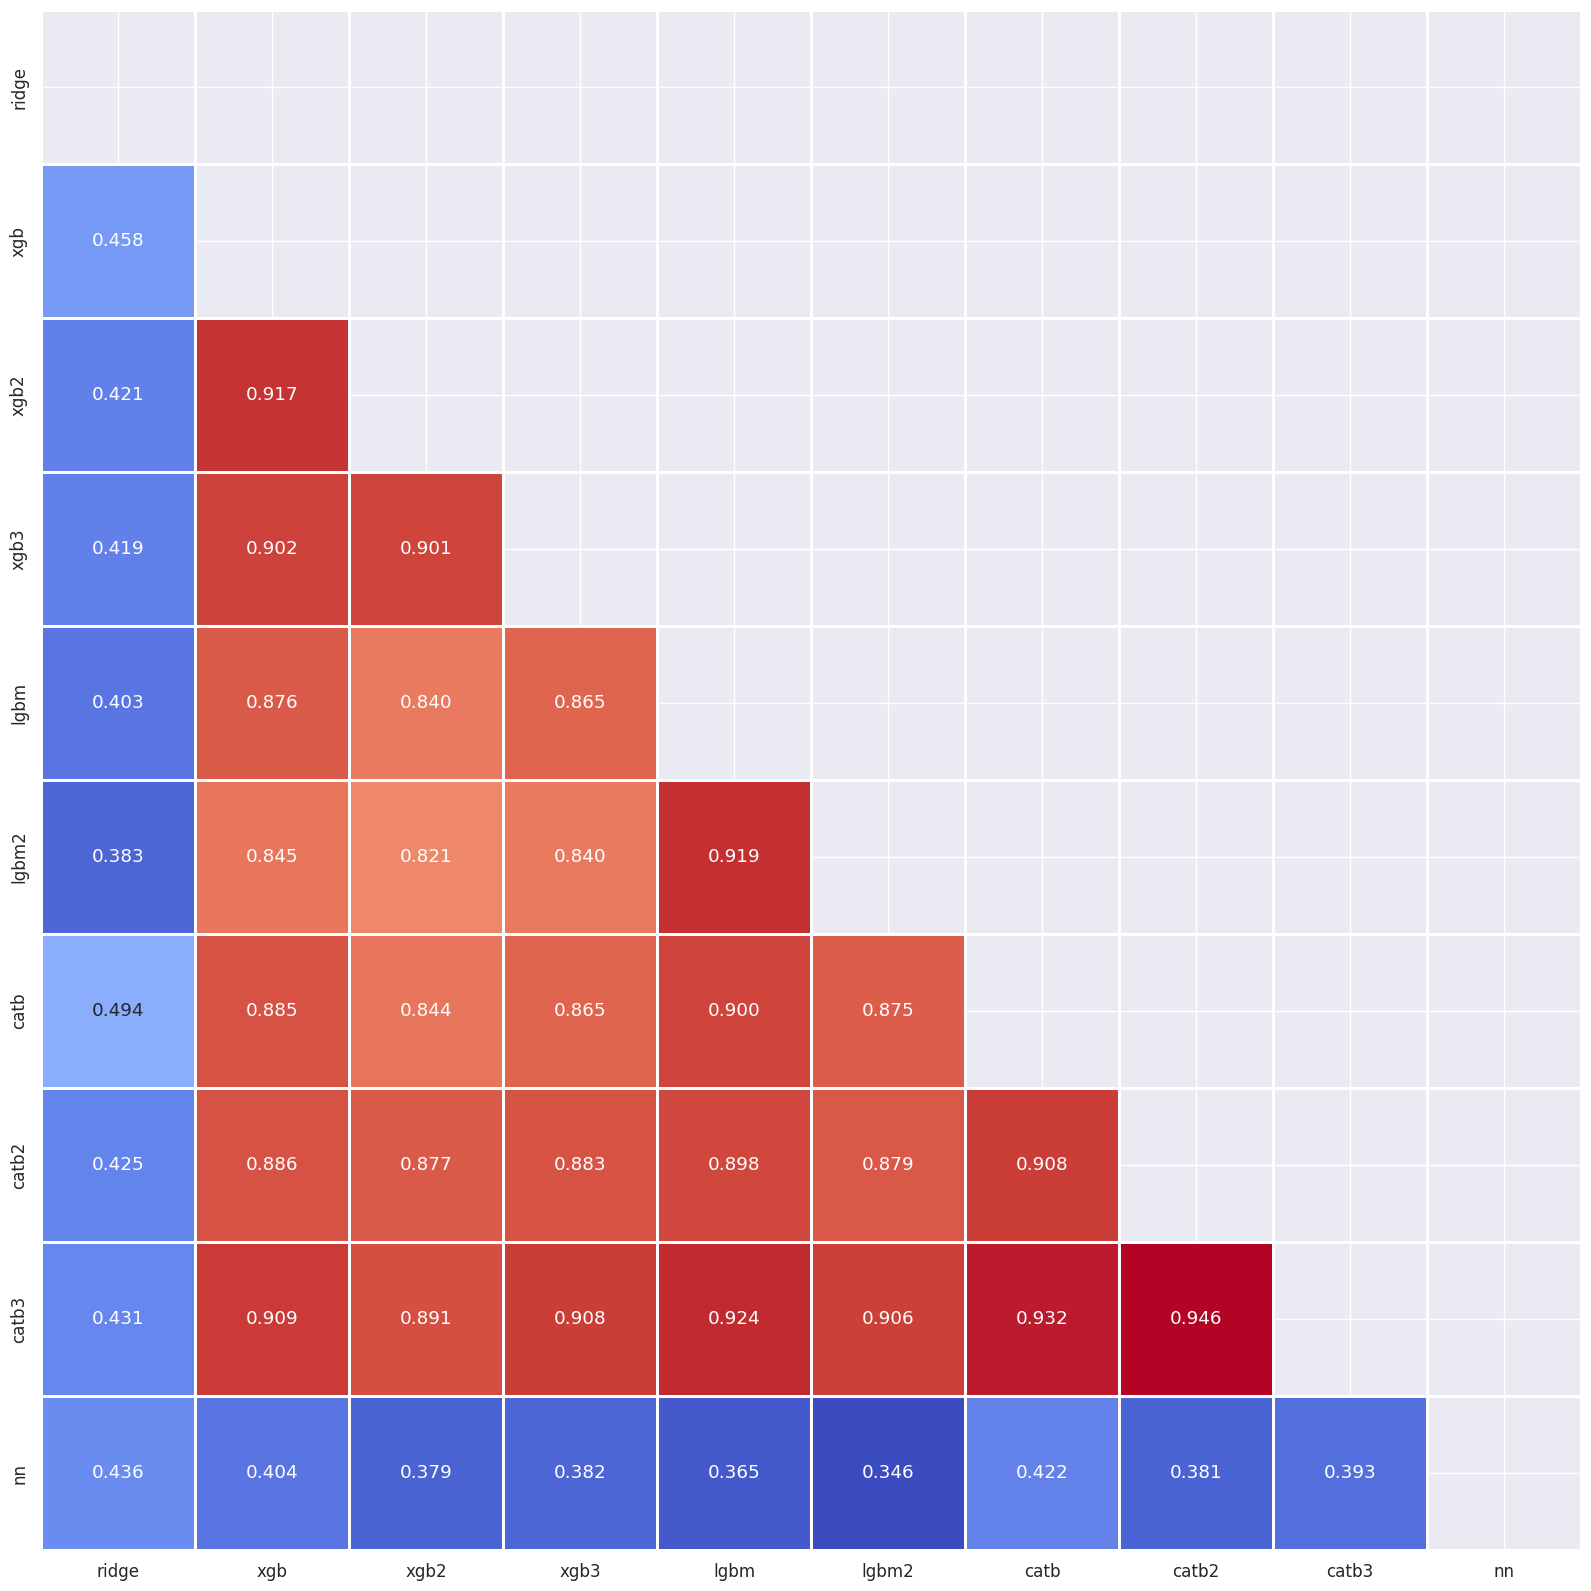

In [45]:
# Model diversity check

sns.set(font_scale=1.1)
correlation_train = oof_predictions_df.corr()
mask = np.triu(correlation_train.corr())
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_train,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            square=True,
            mask=mask,
            linewidths=1,
            cbar=False);

In [46]:
# Model diversity check

#sns.pairplot(oof_predictions_df, corner=True,  palette='viridis')

<a id = "16"></a><br>
# Stacking with Ridge

In [47]:
# Ridge regressor as meta regressor. It uses oof_predictions_df.
def objective(trial):


    max_iter = trial.suggest_int("max_iter", 100, 4000)
    alpha =  trial.suggest_float("alpha", 1e-4, 1000, log=True) 
    tol =  trial.suggest_float("tol", 1e-6, 1e-3, log=True)
     

    
    ensemble_regressor = Ridge(max_iter=max_iter, alpha=alpha,tol=tol, random_state =random_state)
   
    # -- Make a pipeline
    ensemble_pipeline = make_pipeline(StandardScaler(), ensemble_regressor)
    
    
    ss = cv
    score = cross_val_score(ensemble_pipeline, oof_predictions_df, pipe_data.BeatsPerMinute, scoring= "neg_root_mean_squared_error",  cv=ss)
    score = score.mean()
    return score


sampler = TPESampler(seed=random_state) # create a seed for the sampler for reproducibility
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=100)

[I 2025-09-11 13:02:06,166] A new study created in memory with name: no-name-3f4645f0-b946-4a90-8704-8795ce38f542
[I 2025-09-11 13:02:08,790] Trial 0 finished with value: -26.45762598873866 and parameters: {'max_iter': 1561, 'alpha': 451.8560951024097, 'tol': 0.000157029708840554}. Best is trial 0 with value: -26.45762598873866.
[I 2025-09-11 13:02:11,455] Trial 1 finished with value: -26.457629165378343 and parameters: {'max_iter': 2435, 'alpha': 0.0012363188277052211, 'tol': 2.9375384576328313e-06}. Best is trial 0 with value: -26.45762598873866.
[I 2025-09-11 13:02:14,089] Trial 2 finished with value: -26.457628333733908 and parameters: {'max_iter': 326, 'alpha': 115.67327199145953, 'tol': 6.358358856676247e-05}. Best is trial 0 with value: -26.45762598873866.
[I 2025-09-11 13:02:16,745] Trial 3 finished with value: -26.457629165386287 and parameters: {'max_iter': 2862, 'alpha': 0.000139345022513376, 'tol': 0.0008123245085588687}. Best is trial 0 with value: -26.45762598873866.
[I 2

In [48]:
ensemble_params = {
    'max_iter': 969,
    'alpha': 996.2276353844511,
    'tol': 4.41828902390748e-05
}

ridge_ensemble = Ridge(
    **ensemble_params,
    random_state=random_state
)

ensemble_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('ridge_ensemble', ridge_ensemble)
])


In [49]:
min_features_to_select = 1

pipeline = Pipeline([
    ('rfecv', RFECV(
        estimator=ensemble_pipe,                     # scaler -> ridge
        step=1,
        cv = cv,
        scoring="neg_root_mean_squared_error",
        min_features_to_select=min_features_to_select,
        n_jobs=1,
        importance_getter=lambda est: est.named_steps['ridge_ensemble'].coef_
    ))
])

# Fit
pipeline.fit(oof_predictions_df, pipe_data.BeatsPerMinute)

# Results
rfecv_step = pipeline.named_steps['rfecv']
mean_scores = rfecv_step.cv_results_["mean_test_score"]  # negative RMSE
best_idx = np.argmax(mean_scores)
best_rmse = -mean_scores[best_idx]

support = rfecv_step.support_
selected_models = np.array(oof_predictions_df.columns)[support]

print("Best CV RMSE:", best_rmse)
print('Number of evaluated models:', oof_predictions_df.shape[1])
print('Number of selected models:', support.sum())
print('Selected Models for Ensemble:', selected_models)


Best CV RMSE: 26.457567654385038
Number of evaluated models: 10
Number of selected models: 7
Selected Models for Ensemble: ['xgb' 'xgb2' 'xgb3' 'lgbm' 'lgbm2' 'catb' 'catb2']


<a id = "17"></a><br>
# Hill climbing

In [50]:
!pip install hillclimbers

  Preparing metadata (setup.py) ... done
  Created wheel for hillclimbers: filename=hillclimbers-0.1.4-py3-none-any.whl size=4514 sha256=70280964a18639034cb9be2ca58e08072a20d3d7c99e463eeaa0c4dea50da207
  Stored in directory: /root/.cache/pip/wheels/14/ab/ab/0b89edd82e0058e26088cfb1865f49707dba65e05075f12398
Successfully built hillclimbers


In [51]:
from hillclimbers import climb_hill, partial

In [52]:
# Define RMSE metric
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_metric = partial(rmse)


In [53]:
test_preds_hillclimb, oof_preds_hillclimb = climb_hill(
    train=pipe_data,
    oof_pred_df=oof_predictions_df,
    test_pred_df=submission_predictions_df,
    target="BeatsPerMinute",
    objective="minimize",
    eval_metric=rmse_metric,
    negative_weights=True,
    precision=0.001,
    plot_hill=False,
    plot_hist=False,
    return_oof_preds=True )

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (10 total): 

lgbm2: 26.45791 (best solo model)
lgbm:  26.45850
catb3: 26.45858
catb2: 26.45875
xgb3:  26.45905
catb:  26.45927
xgb2:  26.45972
xgb:   26.46019
ridge: 26.46614
nn:    26.47071

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: xgb3 | Best weight: 0.288 | Best rmse: 26.45769
Iteration: 2 | Model added: ridge | Best weight: -0.147 | Best rmse: 26.45755
Iteration: 3 | Model added: catb2 | Best weight: 0.152 | Best rmse: 26.45751
Iteration: 4 | Model added: xgb | Best weight: -0.230 | Best rmse: 26.45741
Iteration: 5 | Model added: xgb2 | Best weight: 0.089 | Best rmse: 26.45739
Iteration: 6 | Model added: lgbm | Best weight: 0.076 | Best rmse: 26.45738
Iteration: 7 | Model added: catb3 | Best weight: -0.026 | Best rmse: 26.45738
Iteration: 8 | Model added: nn | Best weight: 0.007 | Best rmse: 26.45738
Iteration: 9 | Model added: catb | Best weight: 0.0

In [54]:
!pip install cir_model

In [55]:
from cir_model import CenteredIsotonicRegression

rmse_before_calib = rmse(pipe_data.BeatsPerMinute, oof_preds_hillclimb)
print(f"\nHill Climb Ensemble OOF RMSE (Before Calibration): {rmse_before_calib:.6f}")


ir_calibrator = CenteredIsotonicRegression()
ir_calibrator.fit(oof_preds_hillclimb, pipe_data.BeatsPerMinute)
calibrated_oof_preds = ir_calibrator.predict(oof_preds_hillclimb)
rmse_after_calib = rmse(pipe_data.BeatsPerMinute, calibrated_oof_preds)
print(f"Hill Climb Ensemble OOF RMSE (After Isotonic Calibration): {rmse_after_calib:.6f}")

# Calibrate the final test predictions
print("\nCalibrating the final test predictions...")
calibrated_test_preds = ir_calibrator.predict(test_preds_hillclimb)




Hill Climb Ensemble OOF RMSE (Before Calibration): 26.457380
Hill Climb Ensemble OOF RMSE (After Isotonic Calibration): 26.456481

Calibrating the final test predictions...


<a id = "17"></a><br>
# Submission

In [56]:
output = pd.DataFrame({'id': pipe_test.index,
                       'BeatsPerMinute': calibrated_test_preds})

output.to_csv('submission.csv', index=False)